In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [26]:
from datetime import datetime, timedelta

import polars as pl

from tests.helpers.simulation_runner import SimulationTestRunner
from thrs.control.modules.dhw import (
    DHW_MODULE_DESCRIPTION,
    DhwAlarms,
    DhwControl,
    DhwParameters,
)
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    FlowBoundary,
    HvacExchanger,
    OverpressureTemperatureBoundary,
    TemperatureBoundary,
)
from thrs.input_output.modules.dhw import (
    DhwControlValues,
    DhwSensorValues,
    DhwSimulationInputs,
    DhwSimulationOutputs,
)
from thrs.orchestration.collector import PolarsCollector
from thrs.orchestration.runner import SimulatorModel
from thrs.simulation.models.fmu_paths import dhw_path

start_time = datetime.fromtimestamp(0)
# duration = timedelta(minutes=26.9)
duration = timedelta(minutes=60)
time_index = pl.datetime_range(
    start_time, start_time + duration, interval="1m", time_unit="us", eager=True
)

simulation_inputs = DhwSimulationInputs(
    dhw_drives_supply=Boundary(temperature=Stamped.stamp(50), flow=Stamped.stamp(20)),
    dhw_dc_supply=Boundary(temperature=Stamped.stamp(60), flow=Stamped.stamp(60)),
    dhw_adsorption_supply=Boundary(
        temperature=Stamped.stamp(30), flow=Stamped.stamp(45)
    ),
    dhw_ht_supply=Boundary(temperature=Stamped.stamp(70), flow=Stamped.stamp(0)),
    dhw_freshwater_supply=OverpressureTemperatureBoundary(
        temperature=Stamped.stamp(20), overpressure=Stamped.stamp(0.1)
    ),
    dhw_hvac_exchanger=HvacExchanger(
        heat_flow=Stamped.stamp(1000), maximum_temperature=Stamped.stamp(35.0)
    ),
    dhw_seawater_supply=TemperatureBoundary(temperature=Stamped.stamp(20)),
    dhw_hotwater_demand=FlowBoundary(flow=Stamped.stamp(0)),
)


dhw_model = SimulatorModel(
    fmu_path=dhw_path,
    sensor_values_cls=DhwSensorValues,
    control_values_cls=DhwControlValues,
    simulation_outputs_cls=DhwSimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=DhwControl,
    alarms=DhwAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)

with dhw_model.simulation() as simulation:
    runner = SimulationTestRunner.from_module(
        DHW_MODULE_DESCRIPTION, DhwParameters(), simulation
    )

    collector = PolarsCollector()
    runner.run(int(duration.total_seconds()), collector)
    result = collector.result()

[WARNING] State logging: Please enable result storing to get state names


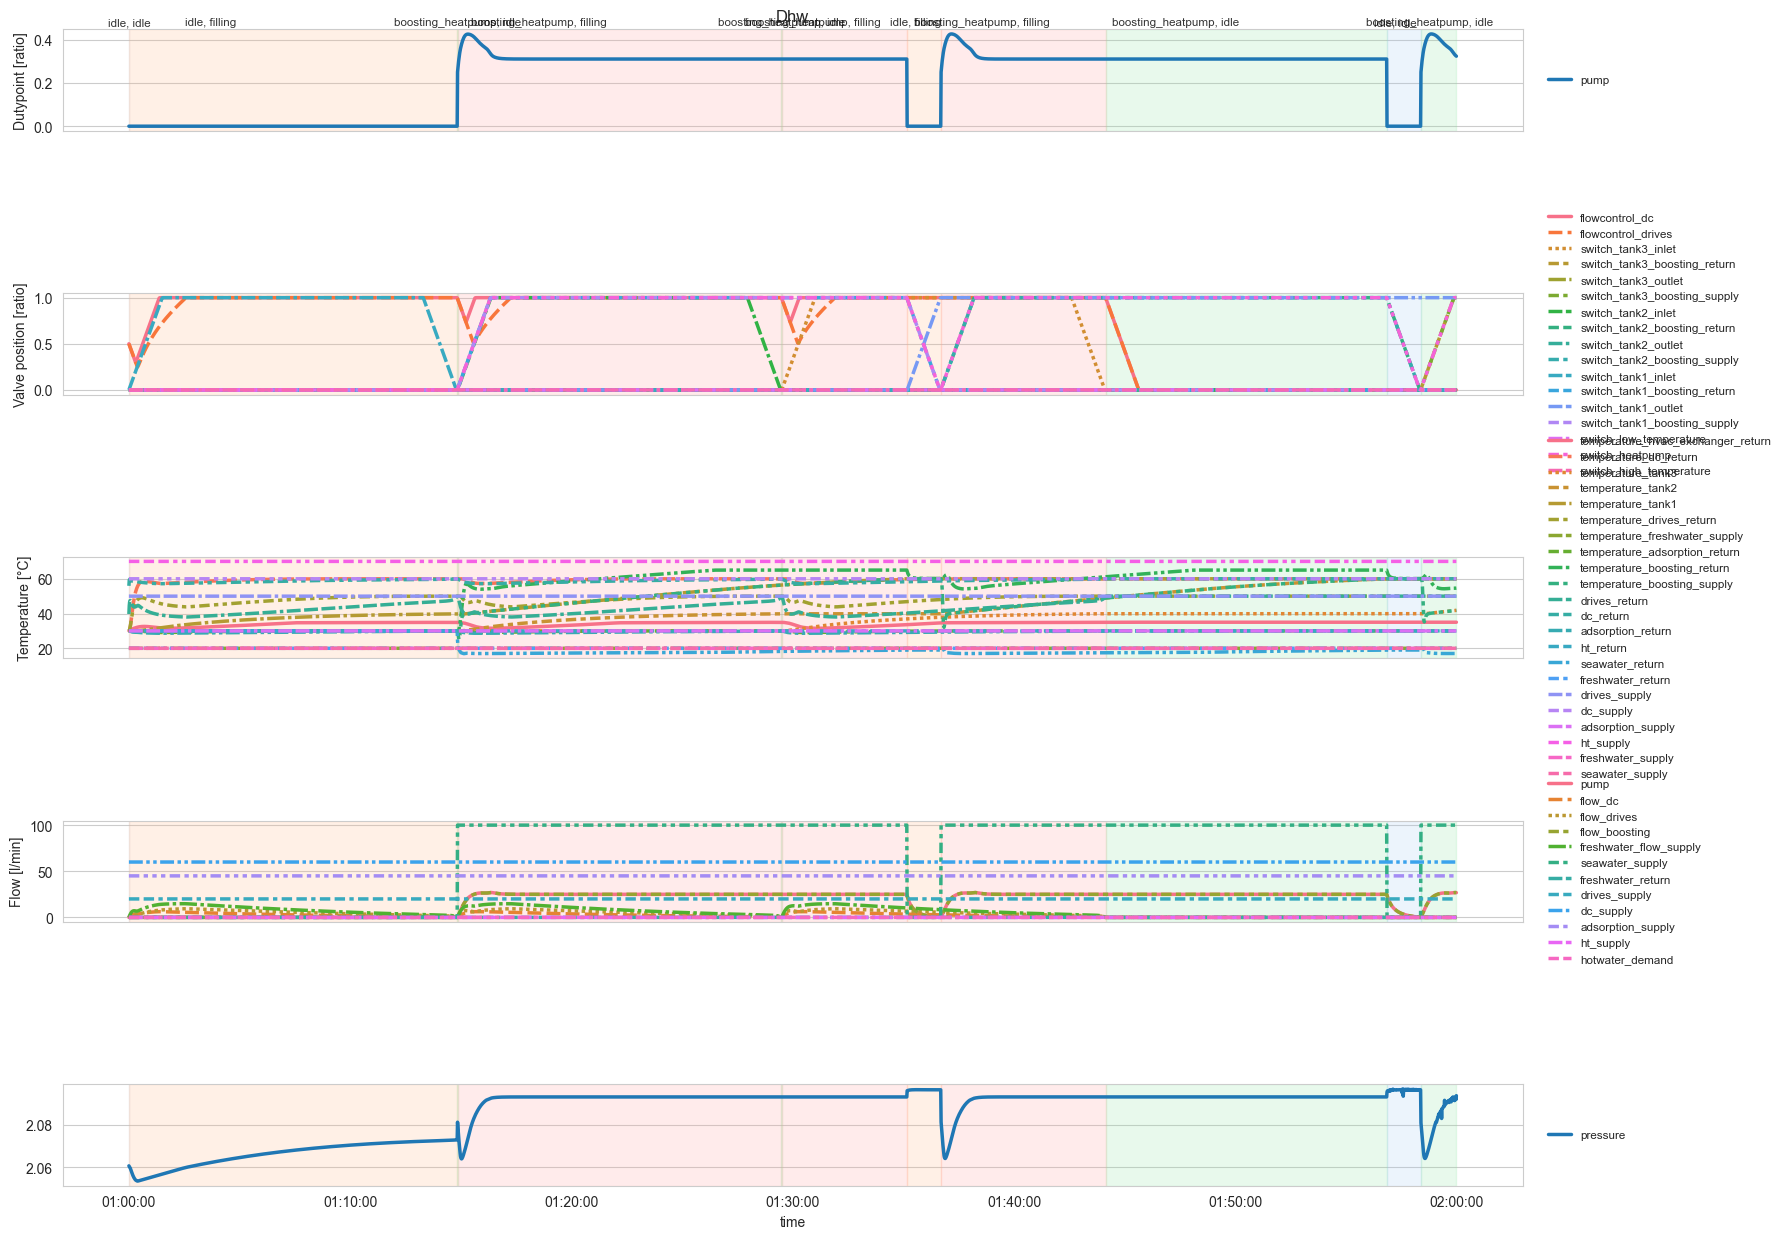

In [27]:
from analysis.analysis_utils import plot_result

plot_result(
    result[
        [
            x
            for x in result.columns
            if x.startswith("dhw") or x in ["time", "control_mode"]
        ]
    ],
    "plots/dhw.png",
);

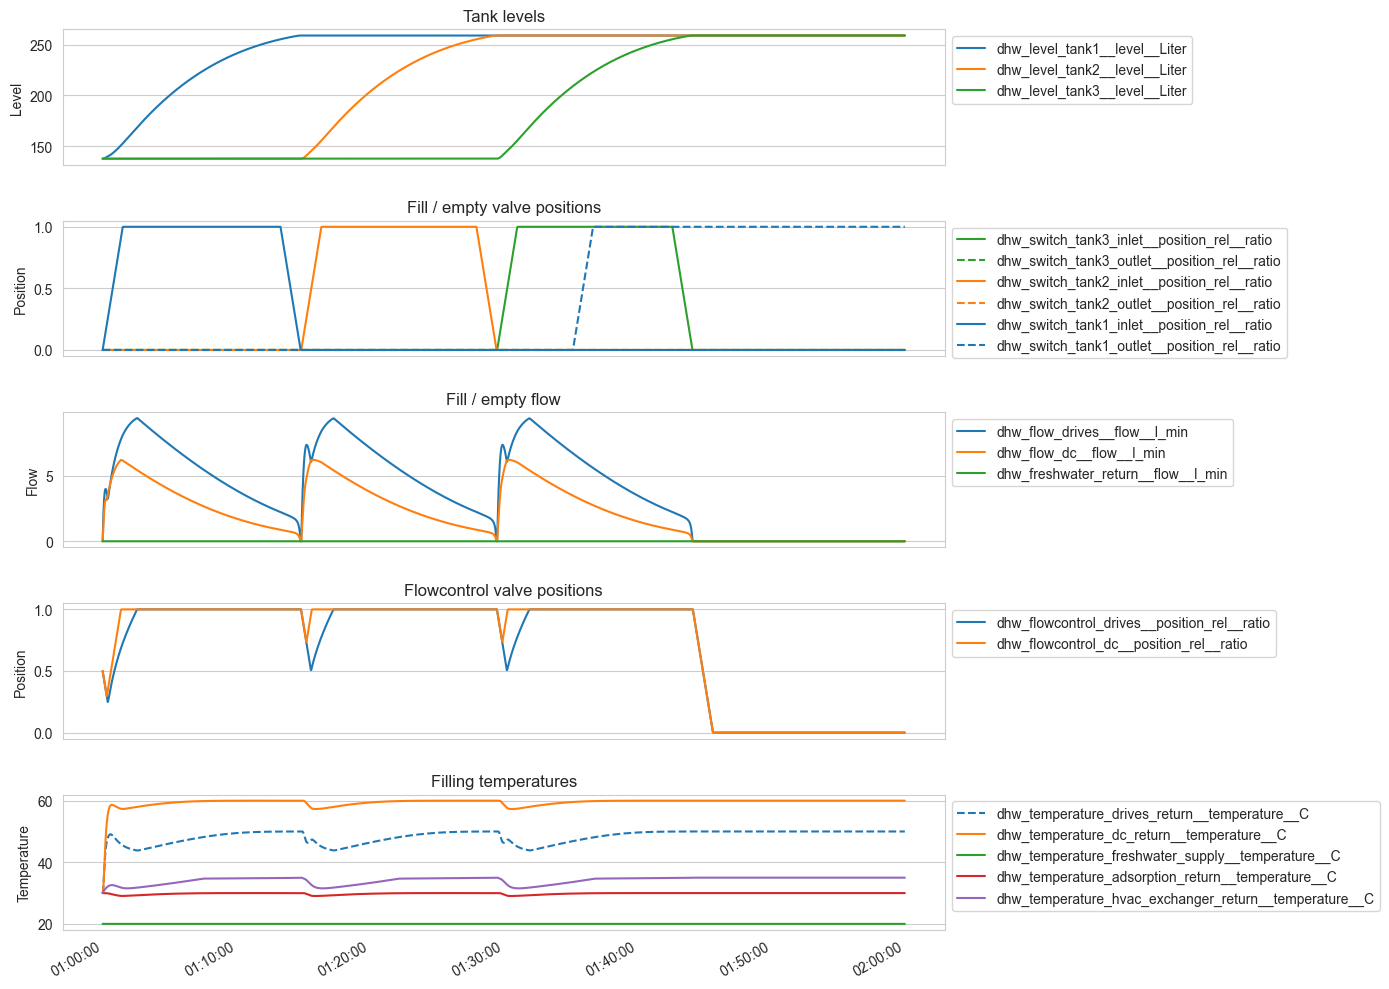

In [28]:
from matplotlib import pyplot as plt
from matplotlib.dates import DateFormatter

levels = [x for x in result.columns if "level" in x]
filling_valves = [
    x
    for x in result.columns
    if ("inlet" in x or "outlet" in x) and ("position_rel" in x)
]
filling_flow = [
    "dhw_flow_drives__flow__l_min",
    "dhw_flow_dc__flow__l_min",
    "dhw_freshwater_return__flow__l_min",
]
flowcontrol_valves = [
    "dhw_flowcontrol_drives__position_rel__ratio",
    "dhw_flowcontrol_dc__position_rel__ratio",
]
filling_temperatures = [
    "dhw_temperature_drives_return__temperature__C",
    "dhw_temperature_dc_return__temperature__C",
    "dhw_temperature_freshwater_supply__temperature__C",
    "dhw_temperature_adsorption_return__temperature__C",
    "dhw_temperature_hvac_exchanger_return__temperature__C",
]


tanks = ["tank1", "tank2", "tank3"]
colors = dict(zip(tanks, plt.rcParams["axes.prop_cycle"].by_key()["color"]))

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
df = result.to_pandas()


for col in levels:
    tank = next((t for t in tanks if t in col), None)
    axes[0].plot(df["time"], df[col], label=col, color=colors.get(tank))
    axes[0].set_ylabel("Level")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[0].set_title("Tank levels")


for col in filling_valves:
    tank = next((t for t in tanks if t in col), None)
    ls = "--" if "outlet" in col else "-"
    axes[1].plot(df["time"], df[col], ls=ls, label=col, color=colors.get(tank))
    axes[1].set_ylabel("Position")
    axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[1].set_title("Fill / empty valve positions")


for col in filling_flow:
    axes[2].plot(df["time"], df[col], label=col)
    axes[2].set_ylabel("Flow")
    axes[2].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[2].set_title("Fill / empty flow")

for col in flowcontrol_valves:
    axes[3].plot(df["time"], df[col], label=col)
    axes[3].set_ylabel("Position")
    axes[3].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[3].set_title("Flowcontrol valve positions")

for col in filling_temperatures:
    ls = "--" if "drives" in col else "-"
    axes[4].plot(df["time"], df[col], label=col, ls=ls)
    axes[4].set_ylabel("Temperature")
    axes[4].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[4].set_title("Filling temperatures")

axes[-1].xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

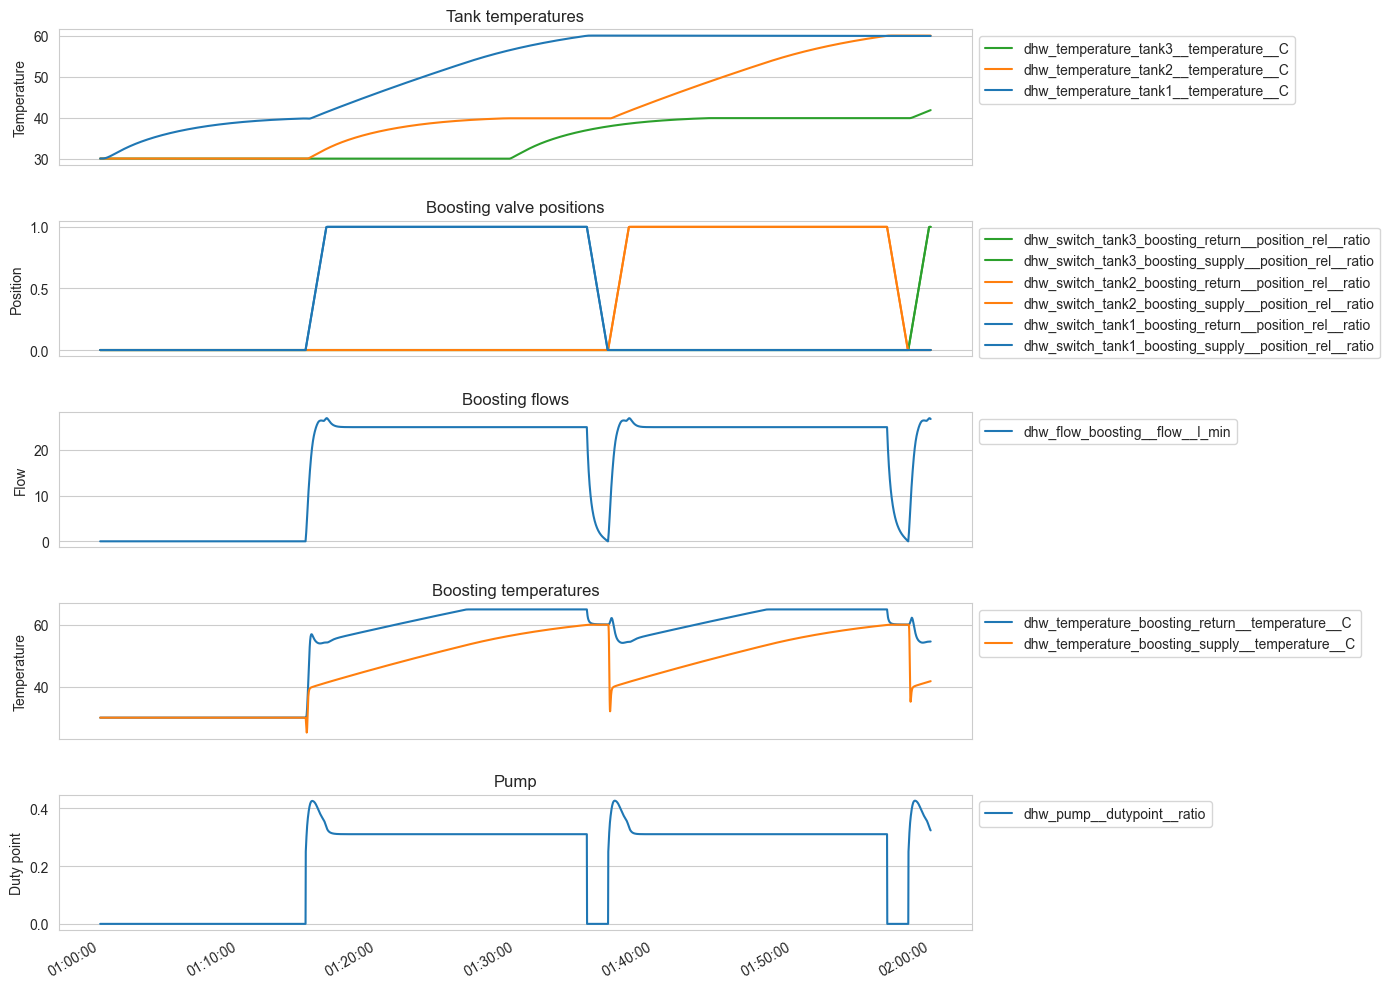

In [29]:
from matplotlib import pyplot as plt

tank_temperatures = [x for x in result.columns if "temperature_tank" in x]
boosting_valves = [
    x
    for x in result.columns
    if ("boosting" in x) and ("switch_tank" in x) and ("position_rel" in x)
]
boosting_flow = [
    x for x in result.columns if ("dhw_flow_boosting" in x) and ("flow__l_min" in x)
]
boosting_temperatures = [x for x in result.columns if ("dhw_temperature_boosting" in x)]


tanks = ["tank1", "tank2", "tank3"]
colors = dict(zip(tanks, plt.rcParams["axes.prop_cycle"].by_key()["color"]))

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
df = result.to_pandas()


for col in tank_temperatures:
    tank = next((t for t in tanks if t in col), None)
    axes[0].plot(df["time"], df[col], label=col, color=colors.get(tank))
    axes[0].set_ylabel("Temperature")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[0].set_title("Tank temperatures")


for col in boosting_valves:
    tank = next((t for t in tanks if t in col), None)
    ls = "--" if "empty" in col else "-"
    axes[1].plot(df["time"], df[col], ls=ls, label=col, color=colors.get(tank))
    axes[1].set_ylabel("Position")
    axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[1].set_title("Boosting valve positions")


for col in boosting_flow:
    axes[2].plot(df["time"], df[col], label=col)
    axes[2].set_ylabel("Flow")
    axes[2].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[2].set_title("Boosting flows")

for col in boosting_temperatures:
    axes[3].plot(df["time"], df[col], label=col)
    axes[3].set_ylabel("Temperature")
    axes[3].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[3].set_title("Boosting temperatures")

for col in ["dhw_pump__dutypoint__ratio"]:
    axes[4].plot(df["time"], df[col], label=col)
    axes[4].set_ylabel("Duty point")
    axes[4].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[4].set_title("Pump")

axes[-1].xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

In [30]:
from transitions.extensions import GraphMachine

control = DhwControl(DhwParameters(), time_fn=datetime.now)
# without further arguments pygraphviz will be used
machine = GraphMachine(
    model=control,
    states=control._states,
    transitions=control._transitions,
    graph_engine="pygraphviz",
    initial="idle",
    show_conditions=True,
    show_state_attributes=True,
)

# draw the whole graph ...
control.get_graph().draw("plots/dhw_state_diagram.png", prog="dot")